In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\akjos\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.shape
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.drop("customerID", axis=1, inplace=True, errors='ignore')
df = df.dropna()  # Drop rows with NaN values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

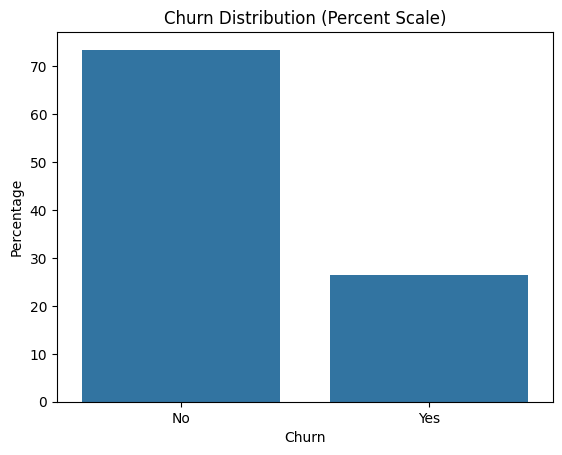

In [7]:
plt.figure() 
ax = sns.countplot(x="Churn", data=df, stat="percent") 

plt.title("Churn Distribution (Percent Scale)") 
plt.ylabel("Percentage") 
plt.show()

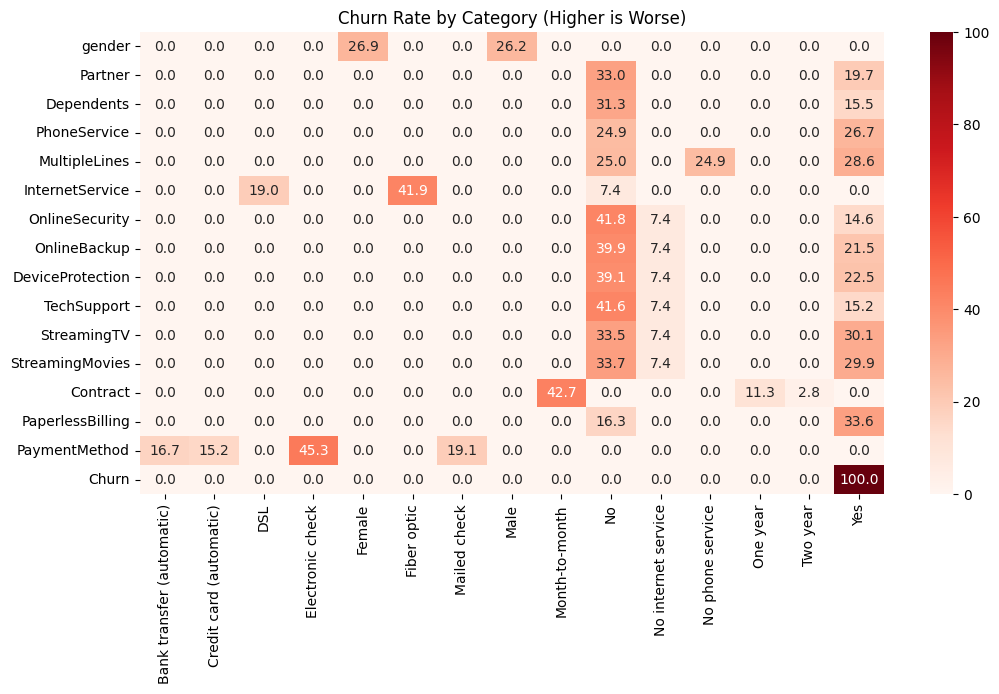

In [13]:
# Calculate churn rate for each categorical variable
churn_summary = {}
for col in df.select_dtypes(include='object').columns:
    churn_summary[col] = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

churn_summary = pd.DataFrame(churn_summary).T
churn_summary = churn_summary.fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(churn_summary, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn Rate by Category (Higher is Worse)")
plt.show()

# This one's a bit confusing, but I am trying to find out churn rates for all objects rather than
# visualizing one by one like contract vs churn, etc. 

# The No's and Yes's are not for churn, they just a choice, for example in partner, it's
# the customer having a partner = yes, if not = no. The actual numbers are churn (saying no 
# to the service) by percentage for category. The 0.0 are just NA values.

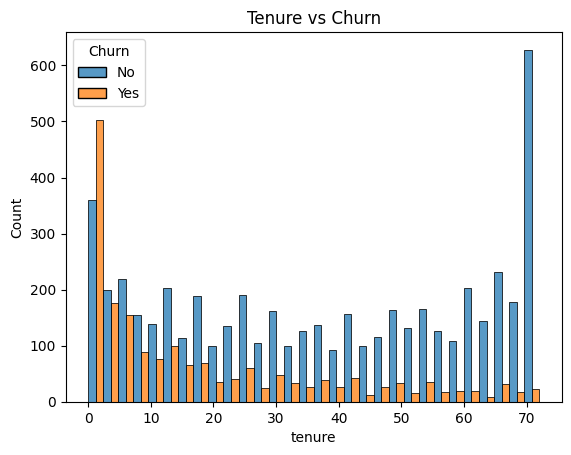

In [14]:
sns.histplot( data=df, x="tenure",hue="Churn",bins=30,multiple="dodge")

plt.title("Tenure vs Churn")
plt.show()

# Tenure = # of months the customer has been with the company.
# We can see that customers with shorter tenure are more likely to churn, 
# while those with longer tenure are less likely to churn.
# This suggests that newer customers may be at higher risk of leaving the service, 
# while long-term customers tend to stay.

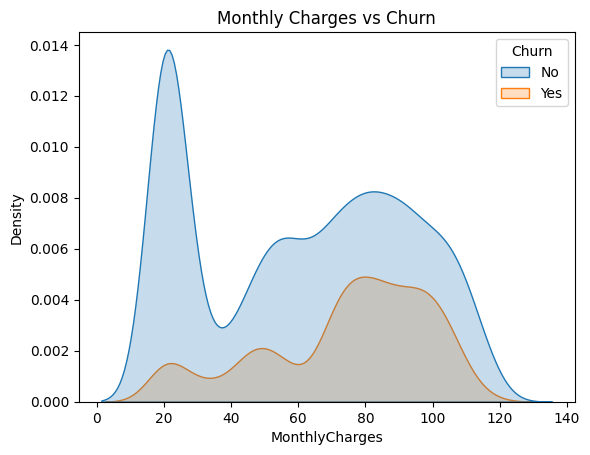

In [15]:
sns.kdeplot( data=df, x="MonthlyCharges",hue="Churn",fill=True)

plt.title("Monthly Charges vs Churn")
plt.show() 

# Customers with higher monthly charges are more likely to churn, 
# while those with lower monthly charges tend to stay.

In [24]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

X = df.drop("Churn", axis=1)
Y = df["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=67)

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.8187633262260128


In [ ]:
print(classification_report(Y_test, y_pred))

# This classification report is fine for capturing customers who will stay, if it predicts a 
# customer will stay, it will be correct 85% of the time, and recall shows it can correctly identify 
# 92% of all customer who did stay. But, this model isn't particularly accurate for customers who did not
# stay probably due to the fact that most customers in this dataset did not churn (>70%), so the model
# trained on 80% of the data might have captured mostly unchurned customers. We will have to fix this
# via balancing the data.

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1028
           1       0.72      0.54      0.62       379

    accuracy                           0.82      1407
   macro avg       0.78      0.73      0.75      1407
weighted avg       0.81      0.82      0.81      1407



In [ ]:
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(X_train, Y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred2))

print(classification_report(Y_test, y_pred2))

# Overall accuracy is lower, but has higher precision for predicting if a customer will churn (92%). 
# The precision has dipped for predicting if a customer will not stay. However, the recall is much
# higher from before (now 80%) as it can now correctly identify 80% of all customers who did churn.

Accuracy: 0.7739872068230277
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1028
           1       0.56      0.80      0.66       379

    accuracy                           0.77      1407
   macro avg       0.73      0.78      0.74      1407
weighted avg       0.82      0.77      0.78      1407



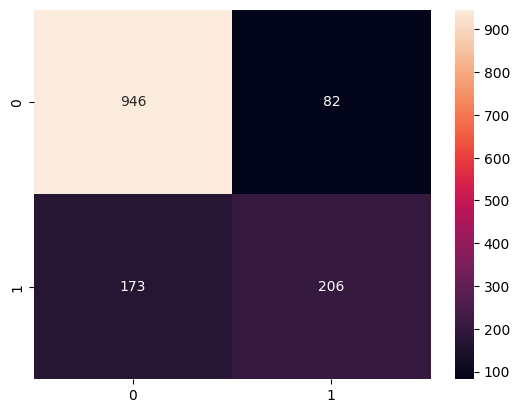

In [ ]:
pred1 = model.predict(X_test)

cm = confusion_matrix(Y_test, pred1)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

# The O's and 1's at the side indicate what the actual churn is (1 = yes, 0 = no), 
# while the ones at the bottom indicate the predicted churn. 

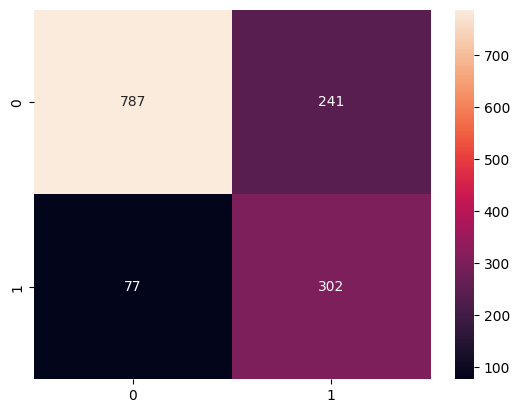

In [ ]:
pred2 = model2.predict(X_test)

cm = confusion_matrix(Y_test, pred2)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

# Both these matrixes are good, but the second one is better for predicting customers who will churn
# as it has less false negatives (predicting a customer will not churn when they actually do) than 
# the first model. So, for that reason, I am going to go with the second model.

In [35]:
y_prob = model2.predict_proba(X_test)[:, 1]

In [ ]:
auc_score = roc_auc_score(Y_test, y_prob)

print("Logistic AUC:", auc_score) 

# AUC score indicates how well a model can distinguish between classes, in this case between a 
# a churn (1) and not churn (0). With a score of 85%, it means there is an 85% chance that the 
# model can correctly rank a churn or not churn. 

Logistic AUC: 0.8527265587302237


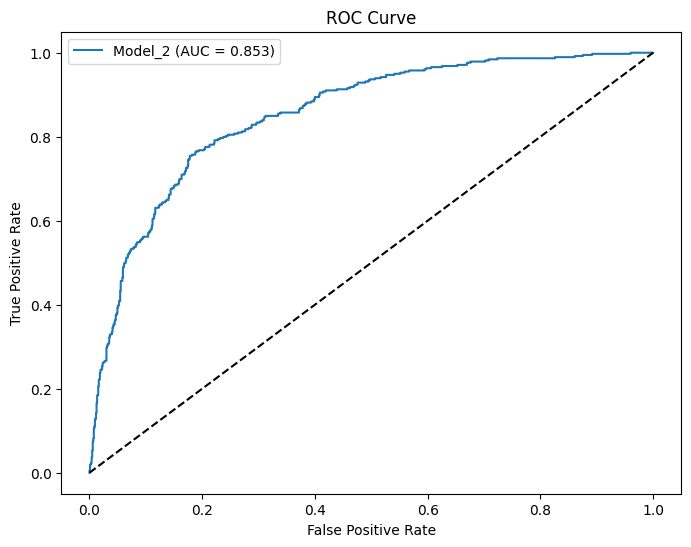

In [38]:
fpr_bal, tpr_bal, _ = roc_curve(Y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_bal, tpr_bal, label=f"Model_2 (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()